# Stock Market Price Forecasting Using Time Series Analysis


## 1. Importing Necessary Libraries and Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
import warnings

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Jupyter magic command (keep only if you're in a notebook)
%matplotlib inline

# Ignore warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the data
data = pd.read_csv("/content/drive/MyDrive/Datasets/Stock Price Pred/yahoo_stock.csv", parse_dates=['Date'])

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1825 non-null   datetime64[ns]
 1   High       1825 non-null   float64       
 2   Low        1825 non-null   float64       
 3   Open       1825 non-null   float64       
 4   Close      1825 non-null   float64       
 5   Volume     1825 non-null   float64       
 6   Adj Close  1825 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 99.9 KB
None


In [ ]:
# Display the first few rows of the dataframe
data.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


In [ ]:
# Ensure the Date column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Set the Date column as the index for the time series
data.set_index('Date', inplace=True)

# Ensure the data is sorted by date
data.sort_index(inplace=True)

# Decompose the Close column
ts_data_close = data['Close']

# Perform seasonal decomposition on the Close column
decomposition = sm.tsa.seasonal_decompose(ts_data_close, model='additive', period=365)

## 2. EDA

In [ ]:
data.isnull().sum()

,0
High,0
Low,0
Open,0
Close,0
Volume,0
Adj Close,0


In [ ]:
data.describe()

,High,Low,Open,Close,Volume,Adj Close
count,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000
mean,2660.718673,2632.817580,2647.704751,2647.856284,3.869627e+09,2647.856284
std,409.680853,404.310068,407.169994,407.301177,1.087593e+09,407.301177
min,1847.000000,1810.099976,1833.400024,1829.079956,1.296540e+09,1829.079956
25%,2348.350098,2322.250000,2341.979980,2328.949951,3.257950e+09,2328.949951
50%,2696.250000,2667.840088,2685.489990,2683.340088,3.609740e+09,2683.340088
75%,2930.790039,2900.709961,2913.860107,2917.520020,4.142850e+09,2917.520020
max,3645.989990,3600.159912,3612.090088,3626.909912,9.044690e+09,3626.909912


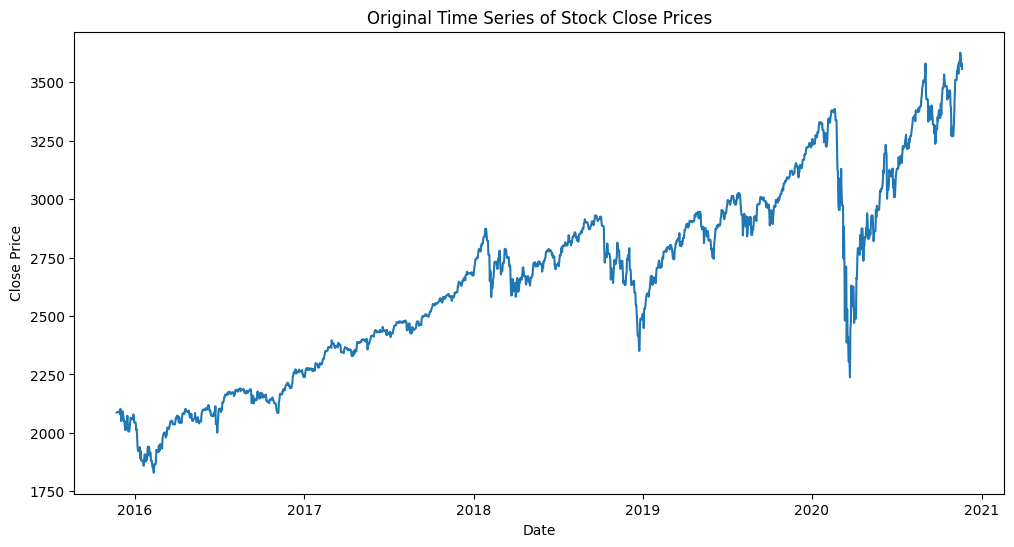

In [ ]:
# Plot the original time series
plt.figure(figsize=(12, 6))
plt.plot(data['Close'])
plt.title('Original Time Series of Stock Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

<Figure size 1200x800 with 0 Axes>

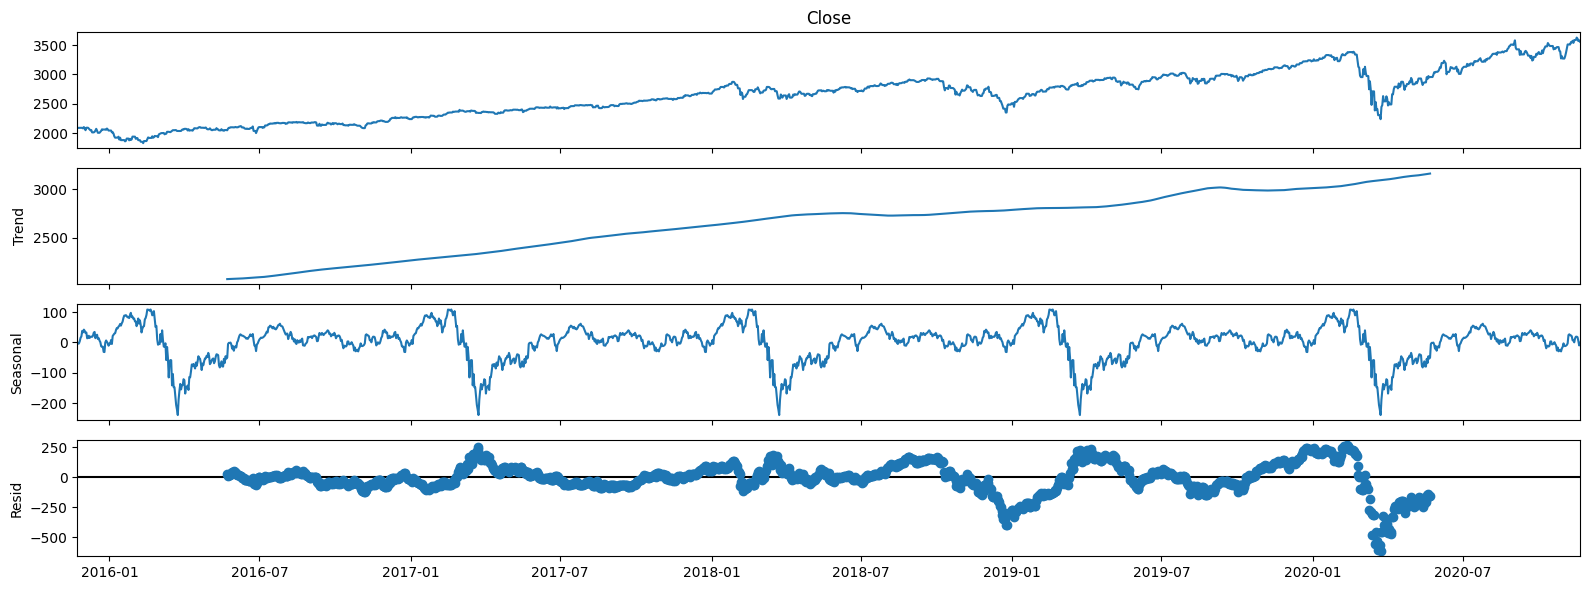

In [ ]:
# Plot the decomposed components
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

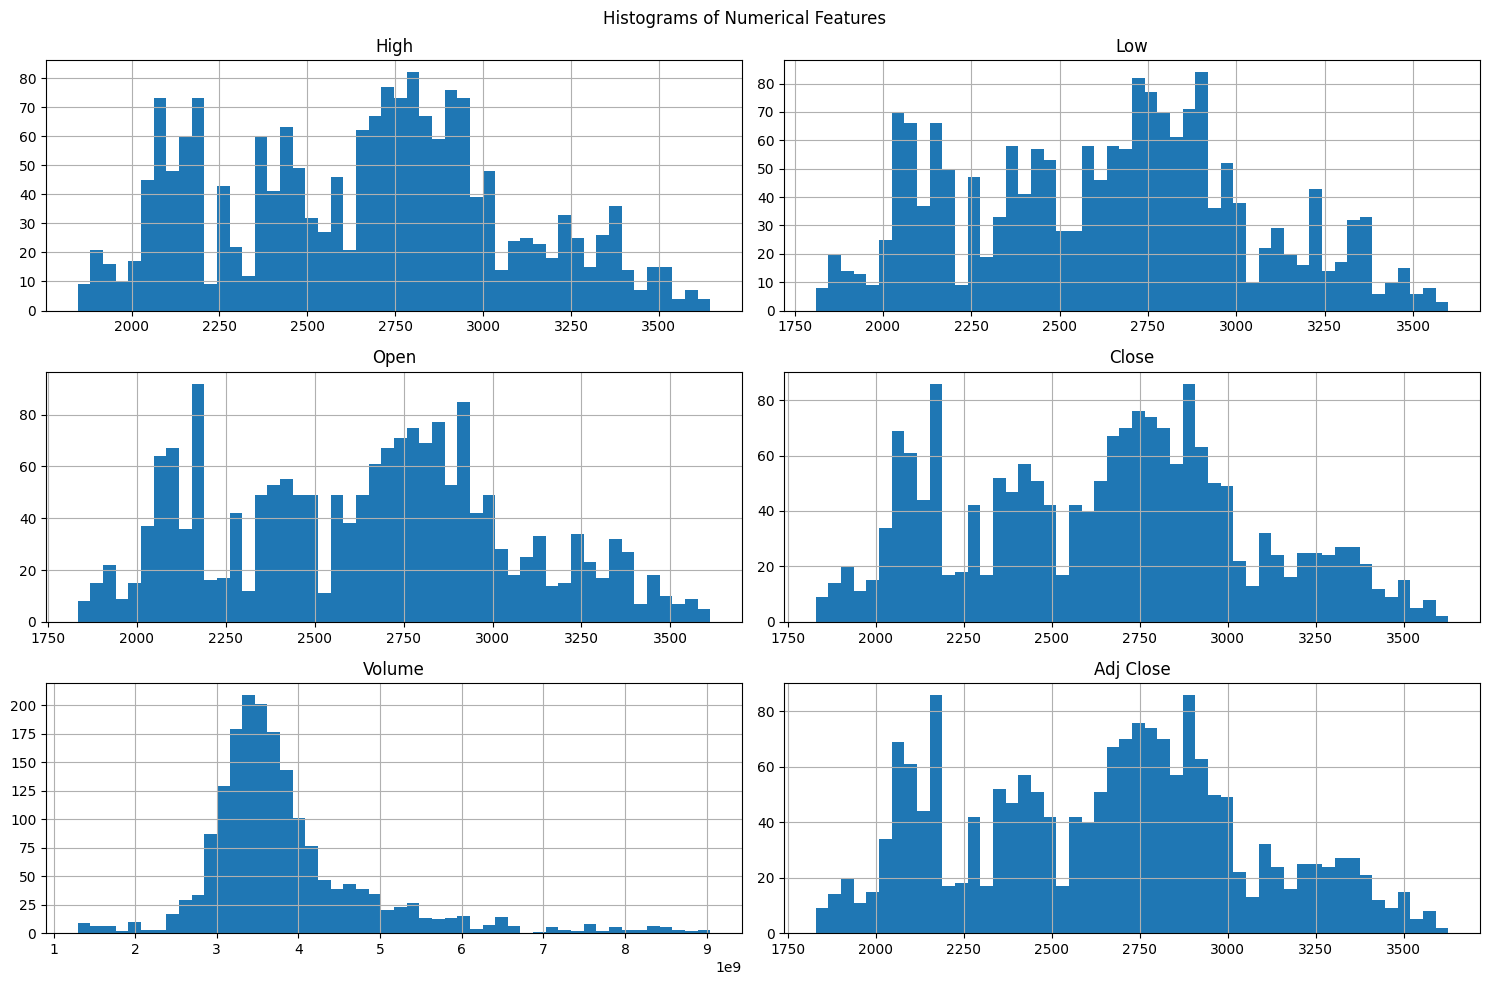

In [ ]:
# Histograms of numerical features
plt.figure(figsize=(12, 6))
data.hist(bins=50, figsize=(15, 10))
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

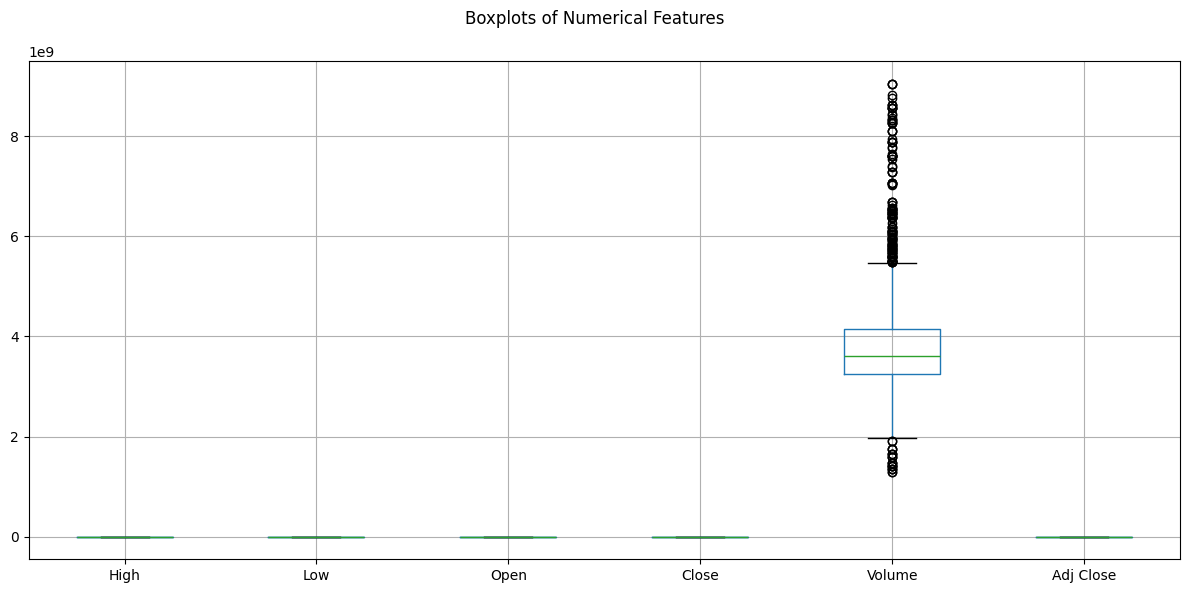

In [ ]:
# Boxplots of numerical features to see outliers
plt.figure(figsize=(12, 6))
data.boxplot(figsize=(15, 10))
plt.suptitle("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the figure size globally
plt.rcParams['figure.figsize'] = [16, 6]

# Define the components and colors for individual plots
components = [
    ('Stock Price', ts_data_close, 'blue'),
    ('Trend Component', decomposition.trend, 'red'),
    ('Seasonal Component', decomposition.seasonal, 'green'),
    ('Residual Component', decomposition.resid, 'purple')
]

# Set up the date locators and formatters
year = mdates.YearLocator()
month = mdates.MonthLocator()
year_format = mdates.DateFormatter('%Y')

# Define the crash period (example, adjust if needed)
crash_start = pd.to_datetime('2020-02-20')
crash_end = pd.to_datetime('2020-04-01')

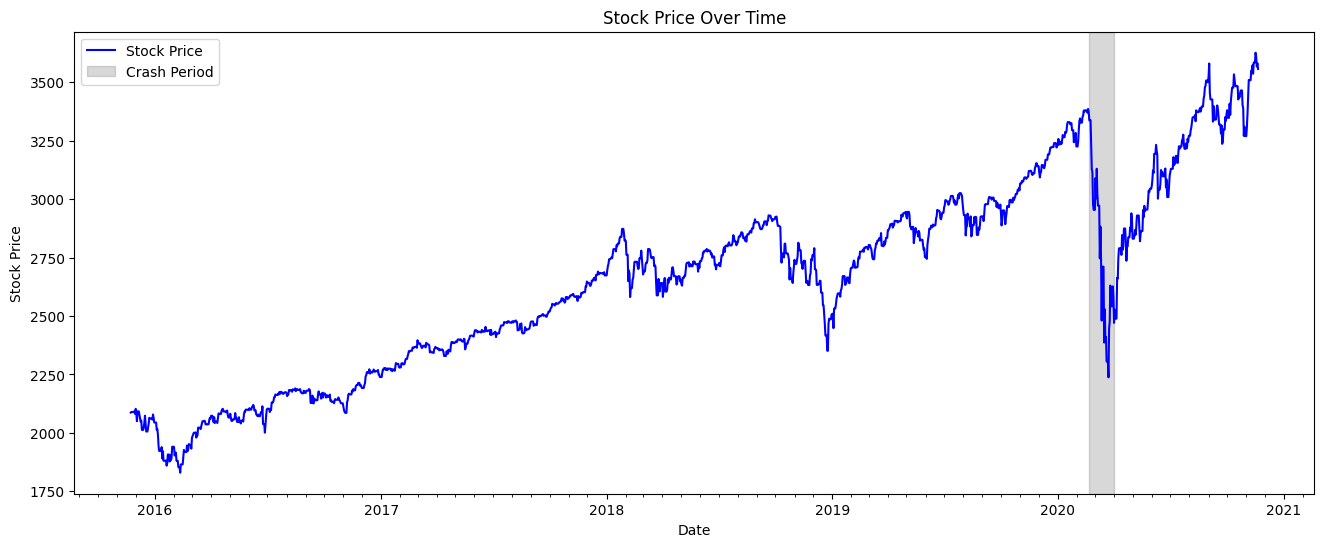

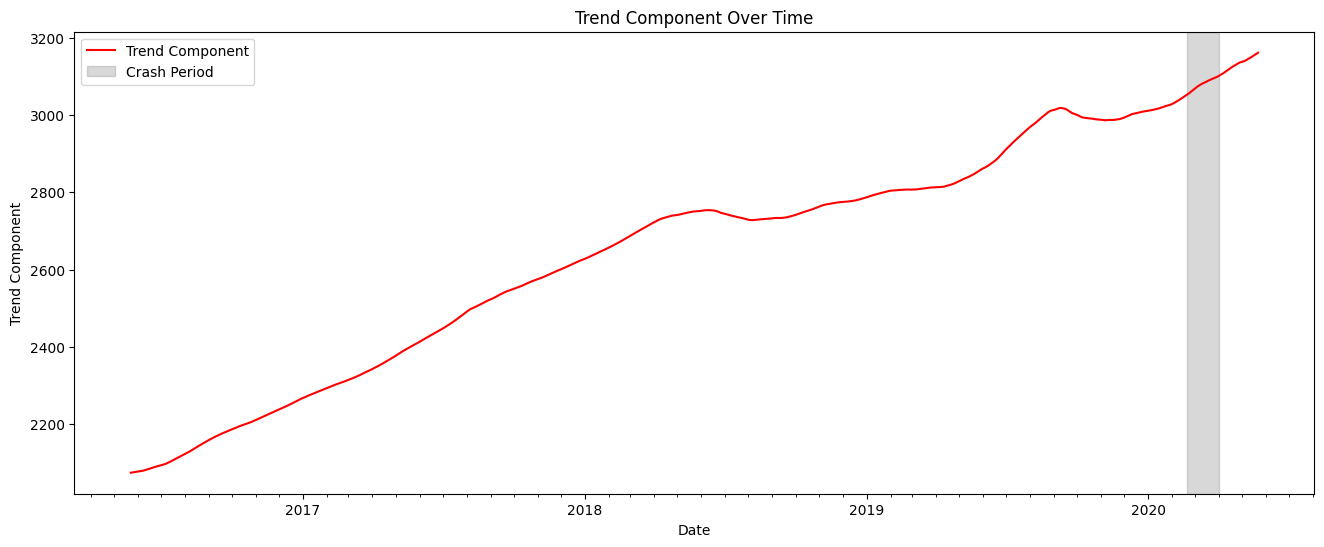

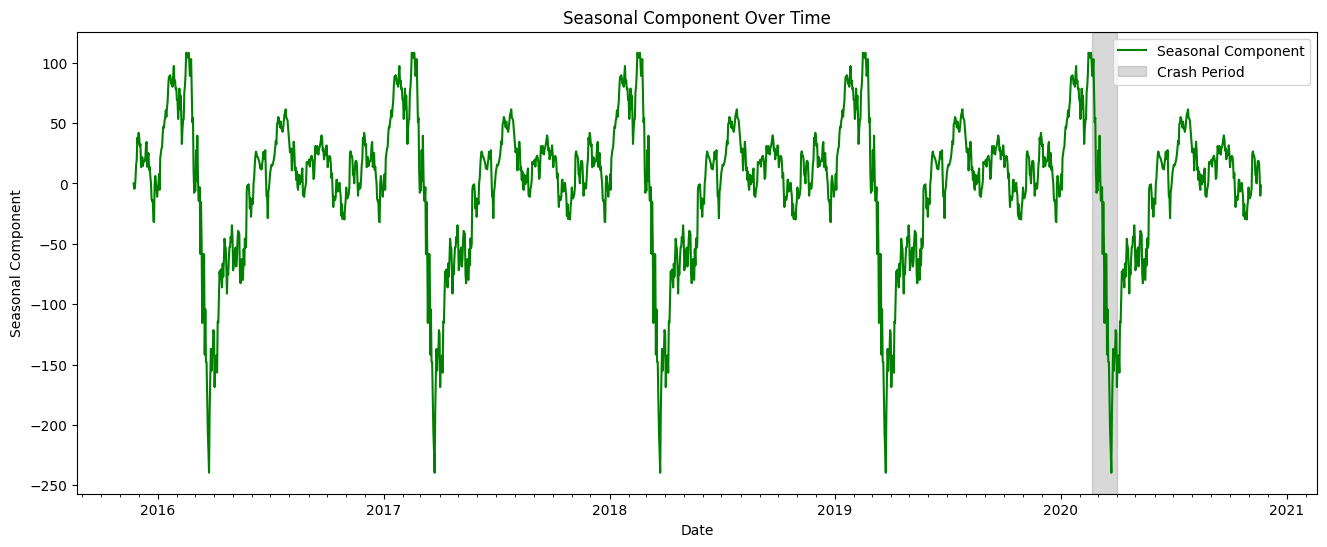

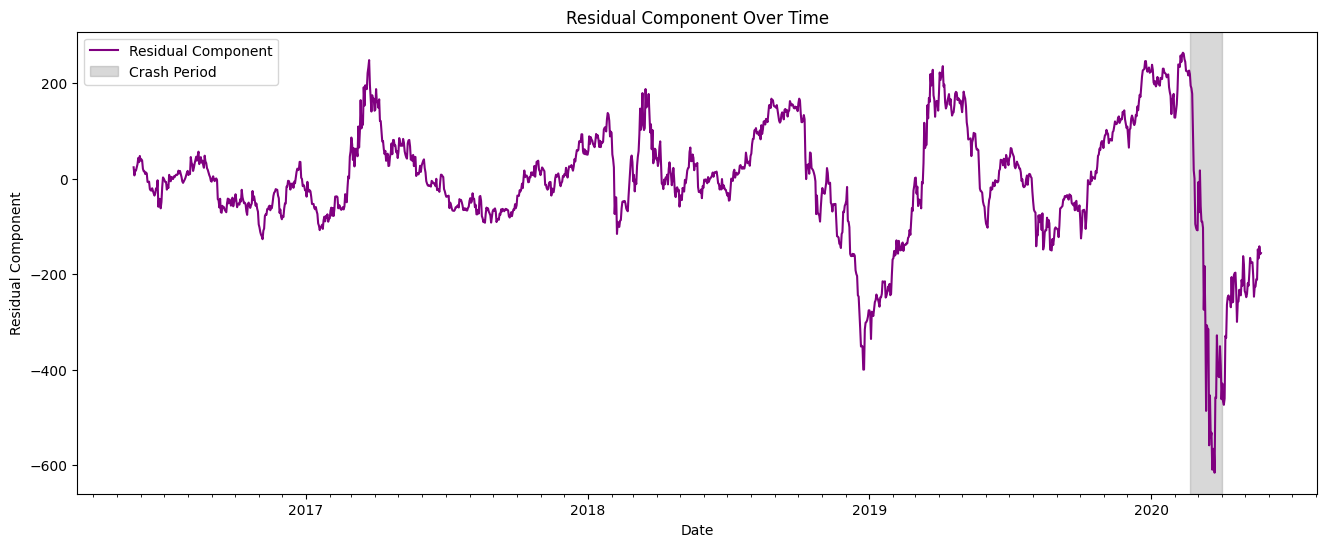

In [ ]:
# Iterate through the components and create individual plots
for title, component, color in components:
    fig, ax = plt.subplots()
    ax.plot(component.index, component, color=color, label=title)

    # Highlight the crash period (optional)
    ax.axvspan(crash_start, crash_end, color='gray', alpha=0.3, label='Crash Period')

    ax.xaxis.set_major_locator(year)
    ax.xaxis.set_major_formatter(year_format)
    ax.xaxis.set_minor_locator(month)
    ax.set_xlabel("Date")
    ax.set_ylabel(title)
    ax.set_title(title + " Over Time")
    ax.legend()
    plt.show()


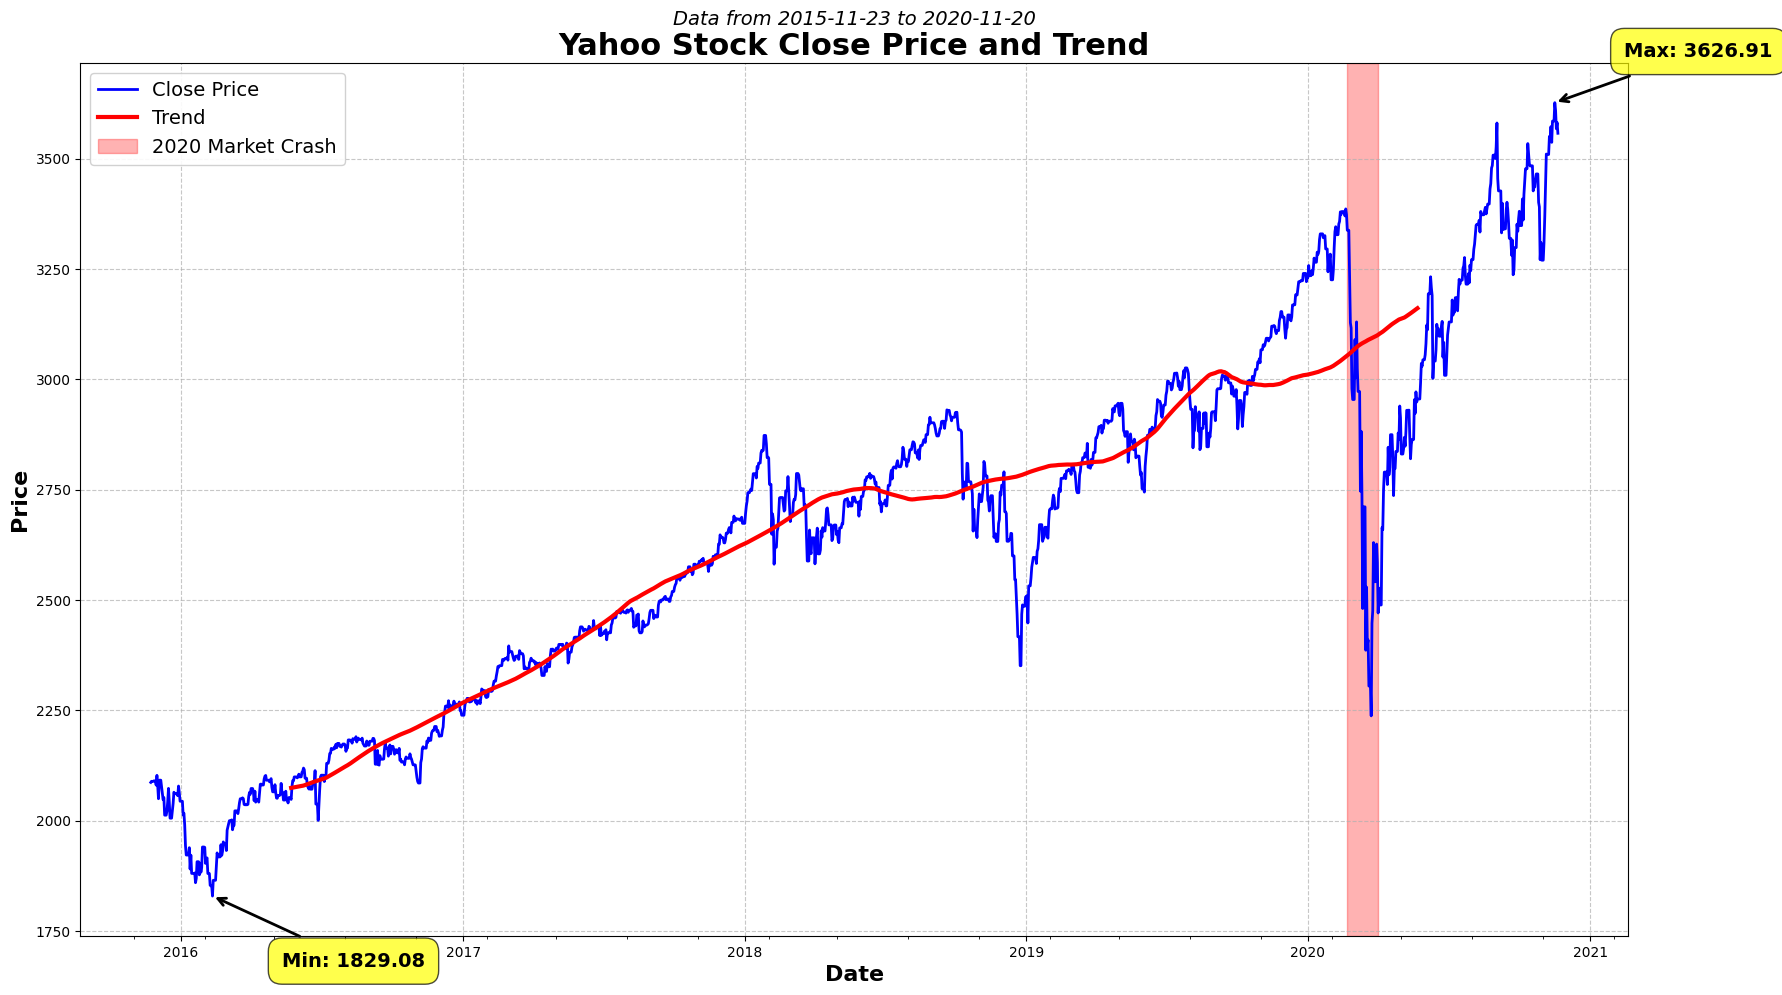

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(18, 10))  # Increased figure size for presentations
ax.grid(True, linestyle='--', alpha=0.7)

# Set up the date locators and formatters
year = mdates.YearLocator()
month = mdates.MonthLocator(interval=3)
year_format = mdates.DateFormatter('%Y')

ax.xaxis.set_major_locator(year)
ax.xaxis.set_major_formatter(year_format)
ax.xaxis.set_minor_locator(month)

# Plot the data with enhanced line width for visibility
ax.plot(data.index, data['Close'], c='blue', label='Close Price', linewidth=2)
ax.plot(decomposition.trend.index, decomposition.trend, c='red', label='Trend', linewidth=3)

# Highlight the 2020 crash with clearer emphasis
crash_start = pd.to_datetime('2020-02-20')
crash_end = pd.to_datetime('2020-04-01')
ax.axvspan(crash_start, crash_end, color='red', alpha=0.3, label='2020 Market Crash')

# Add labels and title with increased size and bold formatting
ax.set_xlabel('Date', fontsize=16, fontweight='bold')
ax.set_ylabel('Price', fontsize=16, fontweight='bold')
ax.set_title('Yahoo Stock Close Price and Trend', fontsize=22, fontweight='bold')

# Add a subtitle with data date range
ax.text(0.5, 1.05, f'Data from {data.index.min().date()} to {data.index.max().date()}',
        horizontalalignment='center', verticalalignment='center', transform=ax.transAxes,
        fontsize=14, style='italic')

# Enhance the legend with larger font size and bold style
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=14, title_fontsize='13')

# Annotate significant points (max and min) with larger text, bold, and arrows
max_point = data['Close'].idxmax()
min_point = data['Close'].idxmin()

ax.annotate(f'Max: {data.loc[max_point, "Close"]:.2f}',
            xy=(max_point, data.loc[max_point, 'Close']),
            xytext=(50, 30), textcoords='offset points',
            ha='left', va='bottom',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.7', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2, connectionstyle='arc3,rad=0'))

ax.annotate(f'Min: {data.loc[min_point, "Close"]:.2f}',
            xy=(min_point, data.loc[min_point, 'Close']),
            xytext=(50, -40), textcoords='offset points',
            ha='left', va='top',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.7', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2, connectionstyle='arc3,rad=0'))

# Adjust layout and display
plt.tight_layout()
plt.show()

## 3. Pre-processing

In [ ]:
# Handle missing values (if any)
data.fillna(method='ffill', inplace=True)  # Forward fill

# Feature scaling (optional, but often beneficial)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Select numerical features to scale
numerical_features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Create lagged features (example: lag of 1 day for 'Close' price)
data['Close_Lag1'] = data['Close'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values created by shifting

# Optional: Feature engineering (e.g., rolling statistics)
data['Close_Rolling_Mean_7'] = data['Close'].rolling(window=7).mean()
data['Close_Rolling_Std_7'] = data['Close'].rolling(window=7).std()
data.dropna(inplace=True) # Drop rows with NaN values created by rolling mean/std

print(data.head())
print(data.info())


                High       Low      Open     Close    Volume  Adj Close  \
Date                                                                      
2015-11-30  0.137194  0.151006  0.144798  0.139796  0.384413   0.139796   
2015-12-01  0.142508  0.152414  0.140289  0.152156  0.311762   0.152156   
2015-12-02  0.143008  0.149163  0.150847  0.139296  0.342546   0.139296   
2015-12-03  0.132296  0.129744  0.139040  0.122670  0.388473   0.122670   
2015-12-04  0.137210  0.134711  0.122472  0.146071  0.376654   0.146071   

            Close_Lag1  Close_Rolling_Mean_7  Close_Rolling_Std_7  
Date                                                               
2015-11-30    0.145192              0.144147             0.001946  
2015-12-01    0.139796              0.145219             0.003618  
2015-12-02    0.152156              0.144475             0.004267  
2015-12-03    0.139296              0.141356             0.009279  
2015-12-04    0.122670              0.141482             0.009345 

## 4. Train, Test and Evaluation

In [ ]:
# Assuming 'data' is your DataFrame with 'Close' as a column and Date as the index
data.index = pd.to_datetime(data.index)

# Split the data
train_size = int(len(data) * 0.8)
test_start_dt = data.index[train_size]

# Create train and test sets
train = data[data.index < test_start_dt][['Close']]
test = data[data.index >= test_start_dt][['Close']]

print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

Training data shape:  (1454, 1)
Test data shape:  (364, 1)


In [ ]:
!pip install pmdarima

In [ ]:
# Scale data to be in range (0, 1)
scaler = MinMaxScaler()
train['Close'] = scaler.fit_transform(train[['Close']])
test['Close'] = scaler.transform(test[['Close']])

In [ ]:
# Specify the number of steps to forecast ahead
HORIZON = 5  # Adjust as needed
print('Forecasting horizon:', HORIZON, 'days')

# Create a test data point for each HORIZON step
test_shifted = test.copy()
for t in range(1, HORIZON):
    test_shifted[f'Close+{t}'] = test_shifted['Close'].shift(-t)
test_shifted = test_shifted.dropna(how='any')

# Define the order and seasonal order for the SARIMAX model
order = (1, 1, 1)  # Perform AIC/BIC optimization to select the best parameters
seasonal_order = (1, 1, 1, 12)  # Adjust this if you have different seasonality

Forecasting horizon: 5 days


In [ ]:
# Make predictions on the test data
training_window = 120  # Increased window size to capture more data
history = list(train['Close'])[-training_window:]

Predicted 1/360
Predicted 101/360
Predicted 201/360
Predicted 301/360
RMSE: 0.031309627946247774


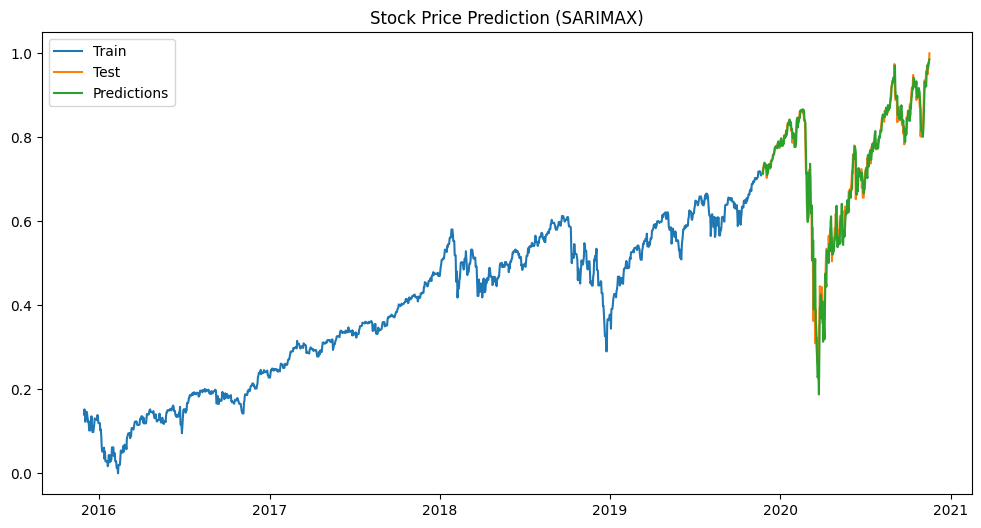

In [ ]:
predictions = []
for t in range(len(test_shifted)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit(disp=False)

    yhat = model_fit.forecast(steps=HORIZON)
    predictions.append(yhat[0])

    obs = list(test_shifted.iloc[t])
    history.append(obs[0])
    history = history[-training_window:]

    if t % 100 == 0:  # Print progress every 100 steps
        print(f'Predicted {t+1}/{len(test_shifted)}')

# Inverse transform predictions and test data
predictions = np.array(predictions).reshape(-1, 1)
predictions = scaler.inverse_transform(predictions).flatten()
test_values = scaler.inverse_transform(test[['Close']])

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_values[:len(predictions)], predictions))
print(f'RMSE: {rmse}')

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(train.index, scaler.inverse_transform(train[['Close']]), label='Train')
plt.plot(test.index[:len(predictions)], test_values[:len(predictions)], label='Test')
plt.plot(test.index[:len(predictions)], predictions, label='Predictions')
plt.legend()
plt.title('Stock Price Prediction (SARIMAX)')
plt.show()


MAE: 0.018862370178157475
MAPE: 26.53%
Results of Dickey-Fuller Test:
Test Statistic                   -0.632315
p-value                           0.863512
#Lags Used                        9.000000
Number of Observations Used    1444.000000
Critical Value (1%)              -3.434887
Critical Value (5%)              -2.863544
Critical Value (10%)             -2.567837
dtype: float64


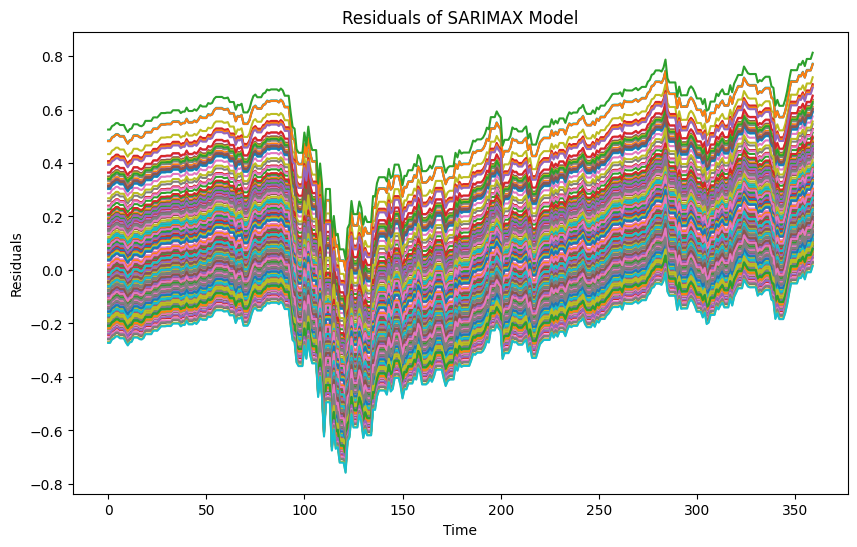

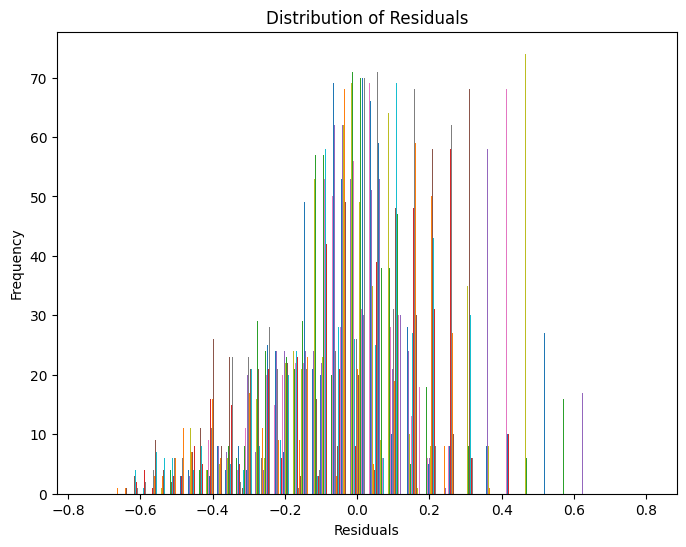

In [ ]:
# Evaluate the model using additional metrics
mae = mean_absolute_error(test_values[:len(predictions)], predictions)
print(f'MAE: {mae}')

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((test_values[:len(predictions)] - predictions) / test_values[:len(predictions)])) * 100
print(f'MAPE: {mape:.2f}%')


# Function to perform ADF test
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

# Test for stationarity on the training data
adf_test(train['Close'])

#Further analysis on residuals:
residuals = test_values[:len(predictions)] - predictions

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals of SARIMAX Model')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.show()


# Histogram of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


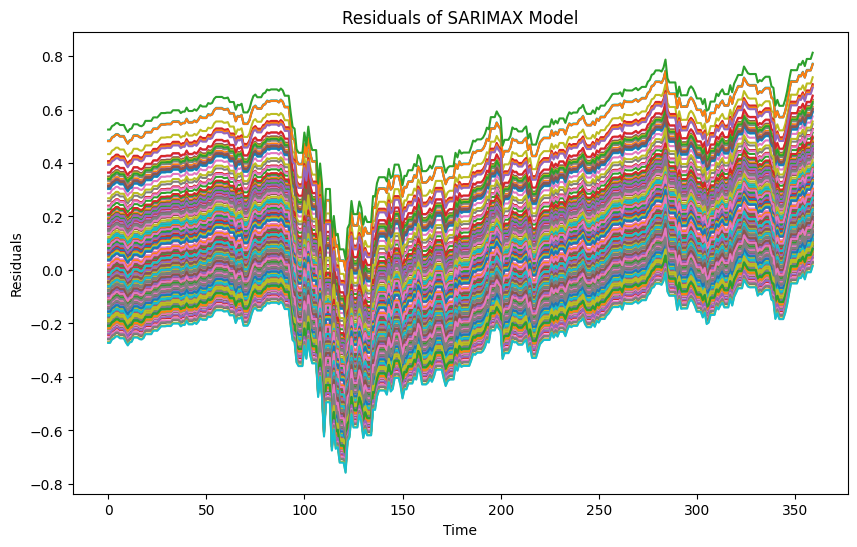

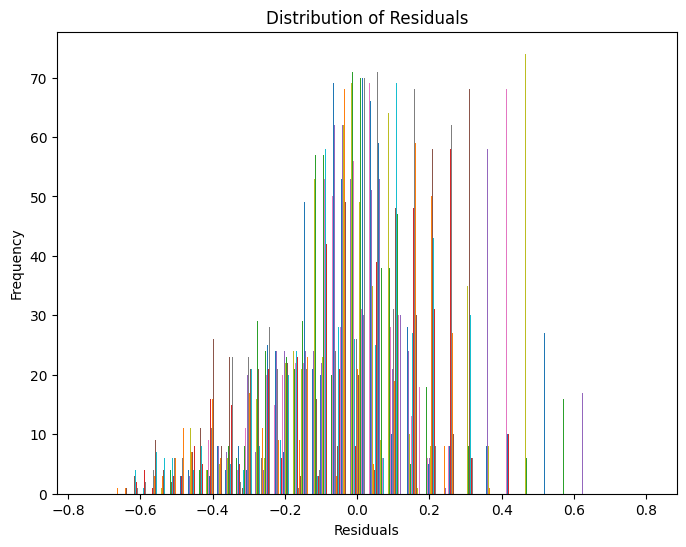

In [ ]:


#Further analysis on residuals:
residuals = test_values[:len(predictions)] - predictions

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals of SARIMAX Model')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.show()


# Histogram of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

         lb_stat  lb_pvalue
10  1.162879e+06        0.0
20  2.124420e+06        0.0


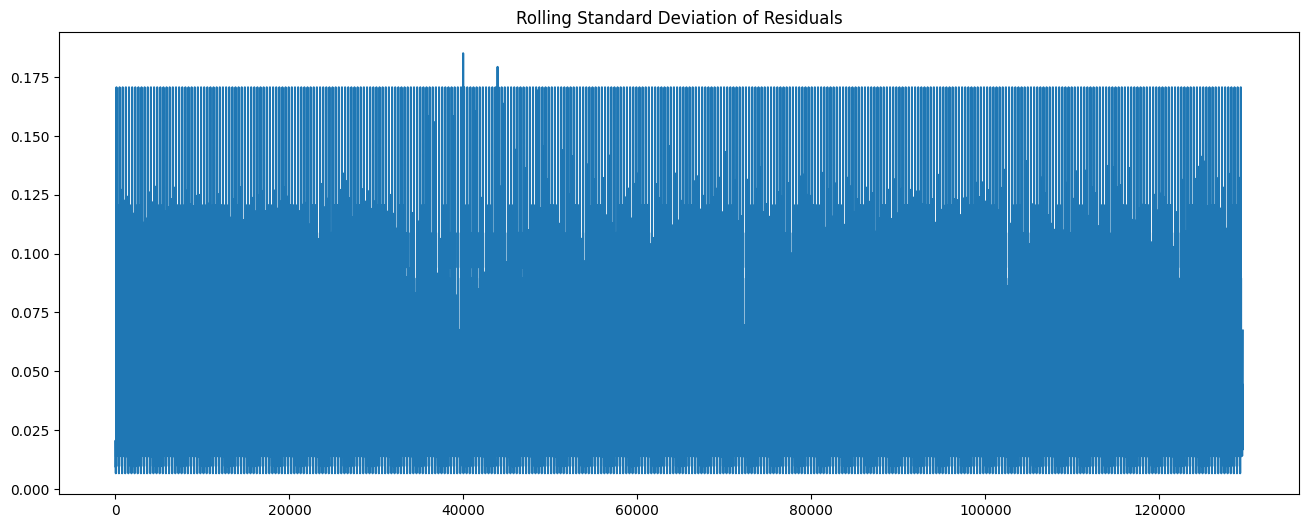

In [ ]:
# Model Diagnostics (Ljung-Box test for residual autocorrelation)
from statsmodels.stats.diagnostic import acorr_ljungbox

# Reshape residuals to 1D array
residuals = residuals.flatten()  # or residuals.reshape(-1)

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True) # Adjust lags as needed
print(lb_test)


# Example: Check for heteroscedasticity using a rolling standard deviation
rolling_std = pd.Series(residuals).rolling(window=20).std() # Adjust window as needed
plt.plot(rolling_std)
plt.title('Rolling Standard Deviation of Residuals')
plt.show()

Ljung-Box Test Results:
          lb_stat  lb_pvalue
1   1.267291e+05        0.0
2   2.510290e+05        0.0
3   3.731542e+05        0.0
4   4.925049e+05        0.0
5   6.091392e+05        0.0
6   7.236066e+05        0.0
7   8.360302e+05        0.0
8   9.465561e+05        0.0
9   1.055555e+06        0.0
10  1.162879e+06        0.0
11  1.268822e+06        0.0
12  1.372383e+06        0.0
13  1.473506e+06        0.0
14  1.572245e+06        0.0
15  1.668916e+06        0.0
16  1.763762e+06        0.0
17  1.856503e+06        0.0
18  1.947435e+06        0.0
19  2.036678e+06        0.0
20  2.124420e+06        0.0

Significant autocorrelation detected at lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Consider adjusting model parameters (p, d, q, P, D, Q, s) or adding more features.


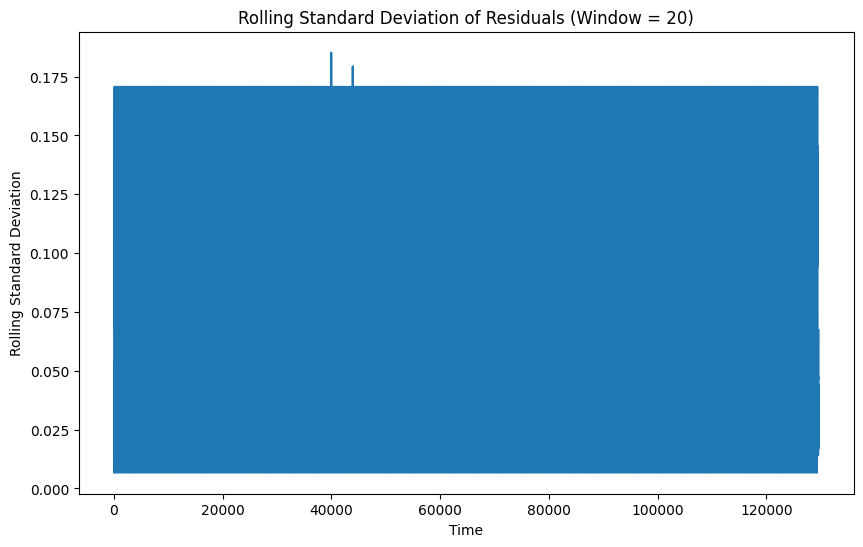


No clear evidence of heteroscedasticity.


In [ ]:
# Model Diagnostics (Ljung-Box test for residual autocorrelation - enhanced)
from statsmodels.stats.diagnostic import acorr_ljungbox

def check_residual_autocorrelation(residuals, max_lag=20):
    """Checks for autocorrelation in residuals using Ljung-Box test.

    Args:
        residuals (array-like): Time series of residuals.
        max_lag (int): Maximum lag for the Ljung-Box test.

    Returns:
        pandas.DataFrame: Results of the Ljung-Box test for multiple lags.
        Prints a summary of the results and potential issues.
    """

    lb_test = acorr_ljungbox(residuals, lags=range(1, max_lag + 1), return_df=True)
    print("Ljung-Box Test Results:\n", lb_test)

    # Identify lags with significant p-values (e.g., p < 0.05)
    significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05].index.tolist()

    if significant_lags:
        print("\nSignificant autocorrelation detected at lags:", significant_lags)
        print("Consider adjusting model parameters (p, d, q, P, D, Q, s) or adding more features.")
    else:
        print("\nNo significant autocorrelation detected.")

    return lb_test

# Example usage:
residuals = test_values[:len(predictions)] - predictions
residuals = residuals.flatten()
lb_results = check_residual_autocorrelation(residuals)

def check_heteroscedasticity(residuals, window=20):
    """Checks for heteroscedasticity in residuals using a rolling standard deviation.

    Args:
      residuals (array-like): Time series of residuals.
      window (int): Window size for the rolling standard deviation.

    Returns:
      pandas.Series: Rolling standard deviation of residuals.
      Prints a summary of the results and potential issues.
    """

    rolling_std = pd.Series(residuals).rolling(window=window).std()
    plt.figure(figsize=(10, 6))
    plt.plot(rolling_std)
    plt.title('Rolling Standard Deviation of Residuals (Window = {})'.format(window))
    plt.xlabel("Time")
    plt.ylabel("Rolling Standard Deviation")
    plt.show()

    if rolling_std.std() > 0.1:  # Or another threshold based on data variability
        print("\nPossible heteroscedasticity detected. Residual variance changes over time.")
        print("Consider transforming the target variable or using a model that handles heteroscedasticity.")
    else:
        print("\nNo clear evidence of heteroscedasticity.")

    return rolling_std

# Example Usage
rolling_std = check_heteroscedasticity(residuals)

In [ ]:
# Shift test predictions for plotting
testPredictPlot = np.empty_like(data['Close'].values.reshape(-1, 1))
testPredictPlot[:, :] = np.nan
testPredictPlot[look_back + len(train_data) : len(data['Close']) -1, :] = test_predict

In [ ]:
# Prepare data for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Example usage:
look_back = 10  # Number of previous time steps to use for prediction
train_data = train['Close'].values.reshape(-1,1) # Reshape to 2D for scaling
test_data = test['Close'].values.reshape(-1, 1)

# Scale the data (if not already scaled)
scaler = MinMaxScaler(feature_range=(0, 1)) # Or use the same scaler from before
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Reshape input to be [samples, time steps, features] which is required for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1))) # You can experiment with different units and layers
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)  # Adjust epochs and batch_size

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert predictions back to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform([y_test])


# Calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(y_train[0], train_predict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(y_test[0], test_predict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# Shift train predictions for plotting
trainPredictPlot = np.empty_like(train_data)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

# Shift test predictions for plotting
testPredictPlot = np.empty_like(data['Close'].values.reshape(-1, 1)) # Use data['Close'] shape
testPredictPlot[:, :] = np.nan
start_index = len(train_predict) + (look_back * 2) + 1
end_index = len(data['Close']) - 1  # Use len(data['Close'])
# Ensure end_index is greater than start_index
end_index = min(end_index, len(testPredictPlot) - 1)
# Check if the slice is valid
if start_index < end_index:
    testPredictPlot[start_index:end_index, :] = test_predict[:(end_index - start_index) +1 , :]
else:
    print("Warning: Test prediction slice is empty. Predictions will not be plotted.")


Epoch 1/50
46/46 - 5s - 101ms/step - loss: 0.0577
Epoch 2/50
46/46 - 0s - 10ms/step - loss: 0.0020
Epoch 3/50
46/46 - 1s - 13ms/step - loss: 8.7346e-04
Epoch 4/50
46/46 - 0s - 11ms/step - loss: 8.1678e-04
Epoch 5/50
46/46 - 1s - 14ms/step - loss: 8.2536e-04
Epoch 6/50
46/46 - 1s - 14ms/step - loss: 8.0736e-04
Epoch 7/50
46/46 - 0s - 10ms/step - loss: 7.8081e-04
Epoch 8/50
46/46 - 1s - 14ms/step - loss: 7.7289e-04
Epoch 9/50
46/46 - 1s - 13ms/step - loss: 7.7842e-04
Epoch 10/50
46/46 - 1s - 14ms/step - loss: 7.5526e-04
Epoch 11/50
46/46 - 0s - 10ms/step - loss: 7.7132e-04
Epoch 12/50
46/46 - 1s - 14ms/step - loss: 7.6424e-04
Epoch 13/50
46/46 - 0s - 11ms/step - loss: 7.5319e-04
Epoch 14/50
46/46 - 1s - 13ms/step - loss: 7.4137e-04
Epoch 15/50
46/46 - 1s - 14ms/step - loss: 7.4796e-04
Epoch 16/50
46/46 - 0s - 11ms/step - loss: 7.3302e-04
Epoch 17/50
46/46 - 1s - 17ms/step - loss: 7.0715e-04
Epoch 18/50
46/46 - 1s - 17ms/step - loss: 8.1129e-04
Epoch 19/50
46/46 - 1s - 17ms/step - loss: 7

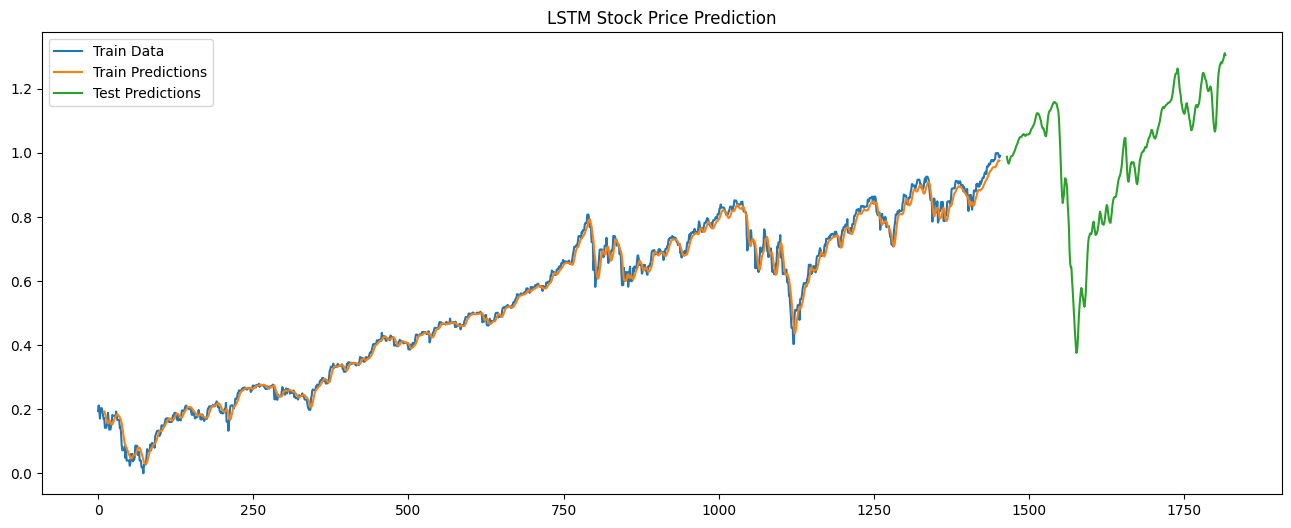

In [ ]:
# Plot baseline and predictions
plt.plot(scaler.inverse_transform(train_data), label='Train Data')
plt.plot(trainPredictPlot, label='Train Predictions')
plt.plot(testPredictPlot, label='Test Predictions')
plt.legend()
plt.title('LSTM Stock Price Prediction')
plt.show()